# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint

## Learning Objective

At the end of the experiment, you will be able to :

* Classify fruits data using KNN classifier
* Visualize the predictions before and after scaling

## Dataset

The dataset chosen for this  experiment is a handmade fruits dataset. The dataset contains 60 records. Each record represents the following details of fruits :

*  Weight -   It is the mass of an object. With respect to this dataset, we have calculated the weights in grams

* Sphericity -   is a measure of how closely the shape of an object approaches that of a mathematically perfect sphere.

* Color -  Every fruit has a different color at different stages. You can encode the color to an integer value. For example

     - Green as 20
     - Greenish Yellow as 40
     - Orange as 60
     - Red as 80
     - Reddish Yellow as 100

*  Label -   We have considered two fruits for simplicity. They are Apple and Orange.




## Setup Steps

In [1]:
#@title Please enter your registration id to start: { run: "auto", display-mode: "form" }
Id = "2418580" #@param {type:"string"}


In [2]:
#@title Please enter your password (normally your phone number) to continue: { run: "auto", display-mode: "form" }
password = "9898989865" #@param {type:"string"}


In [3]:
#@title Run this cell to complete the setup for this Notebook
from IPython import get_ipython

ipython = get_ipython()

notebook= "Demo_KNN_Scaling" #name of the notebook
Answer = "Ungraded"
def setup():
#  ipython.magic("sx pip3 install torch")
    from IPython.display import HTML, display
    ipython.magic("sx wget https://cdn.talentsprint.com/aiml/Experiment_related_data/fruits_weight_sphercity.csv")
    display(HTML('<script src="https://dashboard.talentsprint.com/aiml/record_ip.html?traineeId={0}&recordId={1}"></script>'.format(getId(),submission_id)))
    print("Setup completed successfully")
    return

def submit_notebook():

    ipython.magic("notebook -e "+ notebook + ".ipynb")

    import requests, json, base64, datetime

    url = "https://dashboard.talentsprint.com/xp/app/save_notebook_attempts"
    if not submission_id:
      data = {"id" : getId(), "notebook" : notebook, "mobile" : getPassword()}
      r = requests.post(url, data = data)
      r = json.loads(r.text)

      if r["status"] == "Success":
          return r["record_id"]
      elif "err" in r:
        print(r["err"])
        return None
      else:
        print ("Something is wrong, the notebook will not be submitted for grading")
        return None

    elif getComplexity() and getAdditional() and getConcepts() and getComments():
      f = open(notebook + ".ipynb", "rb")
      file_hash = base64.b64encode(f.read())

      data = {"complexity" : Complexity, "additional" :Additional,
              "concepts" : Concepts, "record_id" : submission_id,
              "id" : Id, "file_hash" : file_hash,
              "feedback_experiments_input" : Comments, "notebook" : notebook}

      r = requests.post(url, data = data)
      r = json.loads(r.text)
      if "err" in r:
        print(r["err"])
        return None
      else:
        print("Your submission is successful.")
        print("Ref Id:", submission_id)
        print("Date of submission: ", r["date"])
        print("Time of submission: ", r["time"])
        print("View your submissions: https://learn-iiith.talentsprint.com/notebook_submissions")
        # print("For any queries/discrepancies, please connect with mentors through the chat icon in LMS dashboard.")
      return submission_id
    else: submission_id


def getAdditional():
  try:
    if not Additional:
      raise NameError
    else:
      return Additional
  except NameError:
    print ("Please answer Additional Question")
    return None
def getComments():
  try:
    if not Comments:
      raise NameError
    else:
      return Comments
  except NameError:
    print ("Please answer Comments Question")
    return None

def getComplexity():
  try:
    if not Complexity:
      raise NameError
    else:
      return Complexity
  except NameError:
    print ("Please answer Complexity Question")
    return None

def getConcepts():
  try:
    if not Concepts:
      raise NameError
    else:
      return Concepts
  except NameError:
    print ("Please answer Concepts Question")
    return None

def getId():
  try:
    return Id if Id else None
  except NameError:
    return None

def getPassword():
  try:
    return password if password else None
  except NameError:
    return None

submission_id = None
### Setup
if getPassword() and getId():
  submission_id = submit_notebook()
  if submission_id:
    setup()

else:
  print ("Please complete Id and Password cells before running setup")


Setup completed successfully


## Import required packages

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
fruits_data = pd.read_csv('fruits_weight_sphercity.csv')
fruits_data.head()

,Color,Weight,Sphericity,labels
0,Red,200,0.40,apple
1,Orange,320,1.00,orange
2,Orange,310,0.95,orange
3,Red,220,0.45,apple
4,Red,230,0.50,apple


In [6]:
# Encode the labels and Color column
fruits_data['Color'] = fruits_data['Color'].replace(['Green', 'Greenish yellow', 'Orange', 'Red','Reddish yellow'],[20, 40, 60, 80, 100])
fruits_data['labels'] = fruits_data['labels'].replace(['apple','orange'],[1, 0])

<ipython-input-6-302009b4ef4e>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fruits_data['Color'] = fruits_data['Color'].replace(['Green', 'Greenish yellow', 'Orange', 'Red','Reddish yellow'],[20, 40, 60, 80, 100])
<ipython-input-6-302009b4ef4e>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fruits_data['labels'] = fruits_data['labels'].replace(['apple','orange'],[1, 0])


In [ ]:
fruits_data.shape

## Take the data samples for training after the interval of  3

In [7]:
# Consider only 20 samples for Train Set
train = fruits_data[0:60:3]
train

,Color,Weight,Sphericity,labels
0,80,200,0.400,1
3,80,220,0.450,1
6,80,240,0.350,1
9,80,243,0.530,1
12,20,259,0.420,1
15,40,260,0.750,0
18,20,266,0.680,0
21,20,220,0.330,1
24,80,210,0.390,1
27,100,270,0.333,1


## Check the length of the dataset

In [8]:
print(len(fruits_data))
print(len(train))
print(type(train))

69
20
<class 'pandas.core.frame.DataFrame'>


In [10]:
# Consider 5 samples for Test set after the interval of 10
test = fruits_data[1:50:10]
test

,Color,Weight,Sphericity,labels
1,60,320,1.00,0
11,20,255,0.60,1
21,20,220,0.33,1
31,20,255,0.69,0
41,80,200,0.48,1


In [11]:
print(len(test))

5


In [12]:
# Features of training data and testing data
traindata = train.iloc[:, 1:3]
testdata = test.iloc[:, 1:3]

In [13]:
traindata.head()

,Weight,Sphericity
0,200,0.40
3,220,0.45
6,240,0.35
9,243,0.53
12,259,0.42


In [14]:
testdata.head()

,Weight,Sphericity
1,320,1.00
11,255,0.60
21,220,0.33
31,255,0.69
41,200,0.48


In [15]:
traindata.shape, testdata.shape

((20, 2), (5, 2))

In [16]:
train.labels

,labels
0,1
3,1
6,1
9,1
12,1
15,0
18,0
21,1
24,1
27,1


## Apply KNN Classifier on the data

In [17]:
from sklearn.neighbors import KNeighborsClassifier
k = 3
neigh = KNeighborsClassifier(n_neighbors=k)

In [18]:
# Train or fit the model with the train data
neigh.fit(traindata, train.labels)

# Test the trained model
predictions = neigh.predict(testdata)

In [19]:
print(predictions, "predictions")
print(test.labels.values, "Actual_labels")

[0 1 1 1 1] predictions
[0 1 1 0 1] Actual_labels


In [20]:
# Stack the test data with predictions (can be used for plotting)
predicted_data = np.column_stack((testdata.iloc[:,:2], predictions))

predicted_df = pd.DataFrame(predicted_data, columns = ['Weight','Sphericity', 'labels'])
predicted_df.head()

,Weight,Sphericity,labels
0,320.0,1.00,0.0
1,255.0,0.60,1.0
2,220.0,0.33,1.0
3,255.0,0.69,1.0
4,200.0,0.48,1.0


## Plot the train, test and predictions before scaling

In [21]:
import matplotlib.pyplot as plt
from mlxtend.plotting import category_scatter

def plotting(traindata, testdata, df_Pred):

  Oranges_train, Oranges_test = traindata[traindata.labels == 0], testdata[testdata.labels == 0]
  Apples_train, Apples_test = traindata[traindata.labels == 1], testdata[testdata.labels == 1]

  Oranges_pred = df_Pred[df_Pred.iloc[:,2] == 0]
  Apples_pred = df_Pred[df_Pred.iloc[:,2] == 1]

  Oranges_train.shape , Apples_train.shape, Oranges_test.shape, Apples_test.shape, Oranges_pred.shape, Apples_pred.shape

  df1 = (pd.concat([Oranges_train, Oranges_test, Apples_train, Apples_test], axis=0, keys=('Oranges_train', 'Oranges_test', 'Apples_train', 'Apples_test'))
          .swaplevel(0,1, axis=0))
  df1 = df1.reset_index(level=1)
  df2 = (pd.concat([Oranges_train, Oranges_pred, Apples_train, Apples_pred], axis=0, keys=('Oranges_train', 'Oranges_pred', 'Apples_train','Apples_pred'))
          .swaplevel(0,1, axis=0))
  df2 = df2.reset_index(level=1)

  fig = category_scatter(x='Sphericity', y='Weight', label_col='level_1',
                        data=df1, markers='*o*o', colors=('red', 'red', 'green', 'green'), markersize=50, legend_loc='upper left')

  fig = category_scatter(x='Sphericity', y='Weight', label_col='level_1',
                        data=df2, markers='*o*o', colors=('red', 'red', 'green', 'green'), markersize=50, legend_loc='upper left')

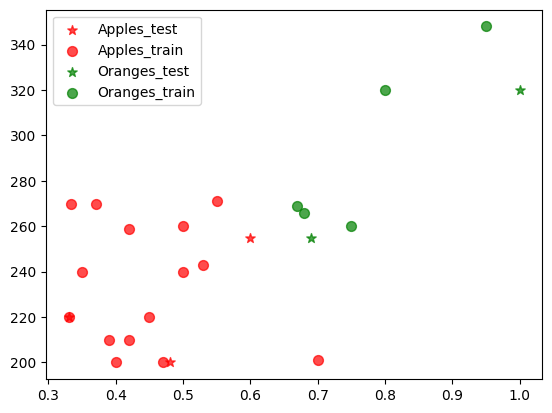

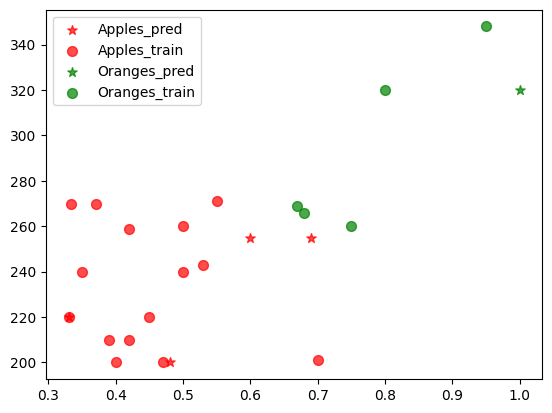

In [22]:
plotting(train, test, predicted_df)

## Scaling the data

In [23]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [24]:
# Data Before Scaling
fruits_data.head()

,Color,Weight,Sphericity,labels
0,80,200,0.40,1
1,60,320,1.00,0
2,60,310,0.95,0
3,80,220,0.45,1
4,80,230,0.50,1


In [25]:
fruits_data[['Sphericity', 'Weight']] = scaler.fit_transform(fruits_data[['Sphericity', 'Weight']])

In [26]:
# Data After Scaling
fruits_data.head()

,Color,Weight,Sphericity,labels
0,80,0.000000,0.333333,1
1,60,0.774194,1.000000,0
2,60,0.709677,0.944444,0
3,80,0.129032,0.388889,1
4,80,0.193548,0.444444,1


### Take the data samples for training after the interval of  3

In [27]:
Train = fruits_data[0:60:3]
Train.head()

,Color,Weight,Sphericity,labels
0,80,0.000000,0.333333,1
3,80,0.129032,0.388889,1
6,80,0.258065,0.277778,1
9,80,0.277419,0.477778,1
12,20,0.380645,0.355556,1


In [28]:
Test = fruits_data[1:50:10]
Test

,Color,Weight,Sphericity,labels
1,60,0.774194,1.000000,0
11,20,0.354839,0.555556,1
21,20,0.129032,0.255556,1
31,20,0.354839,0.655556,0
41,80,0.000000,0.422222,1


In [29]:
print(len(Test))

5


### Apply KNN Classifier on the scaled data

In [30]:
from sklearn.neighbors import KNeighborsClassifier
k = 3
Neigh = KNeighborsClassifier(n_neighbors=k)

In [31]:
# Convert dataframe into array
Traindata = Train.iloc[:,1:3]
Testdata = Test.iloc[:,1:3]

In [32]:
# Train or fit the model with the train data
neigh.fit(Traindata, Train.labels)

# Test the trained model
scaled_predictions = neigh.predict(Testdata)

In [33]:
print(scaled_predictions,"predictions")
print(Test.labels.values,"labels")

[0 1 1 0 1] predictions
[0 1 1 0 1] labels


In [34]:
predicted_data = np.column_stack((Testdata.iloc[:,:2], scaled_predictions))

df_Pred_scale = pd.DataFrame(predicted_data, columns = ['Weight','Sphericity', 'labels'])
df_Pred_scale.head()

,Weight,Sphericity,labels
0,0.774194,1.000000,0.0
1,0.354839,0.555556,1.0
2,0.129032,0.255556,1.0
3,0.354839,0.655556,0.0
4,0.000000,0.422222,1.0


### Plot the train and test points after scaling

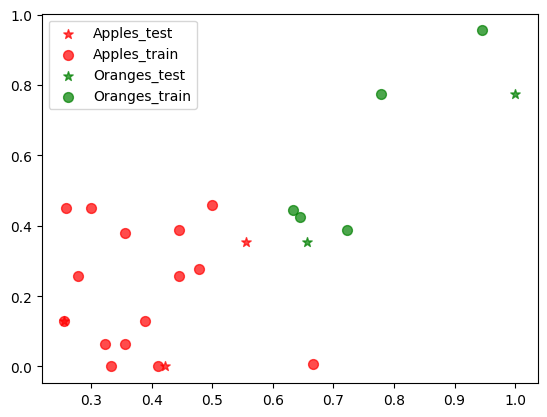

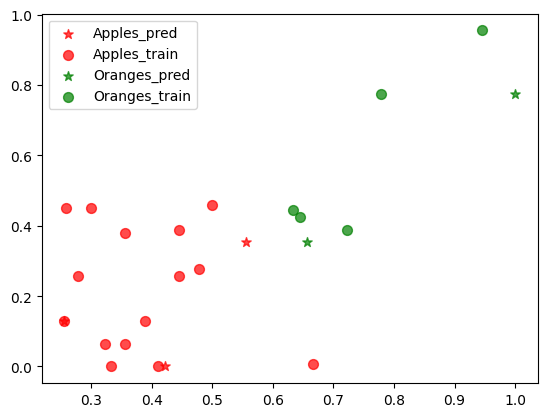

In [35]:
plotting(Train, Test, df_Pred_scale)

## Please answer the questions below to complete the experiment:

In [36]:
#@title How was the experiment? { run: "auto", form-width: "500px", display-mode: "form" }
Complexity = "Good and Challenging for me" #@param ["","Too Simple, I am wasting time", "Good, But Not Challenging for me", "Good and Challenging for me", "Was Tough, but I did it", "Too Difficult for me"]


In [37]:
#@title If it was very easy, what more you would have liked to have been added? If it was very difficult, what would you have liked to have been removed? { run: "auto", display-mode: "form" }
Additional = "d\"sad\"smore you\" would have liked to have been added? If it was very \"difficult, what would you have liked to have been removed? [ ] Additional:" #@param {type:"string"}

In [38]:
#@title Can you identify the concepts from the lecture which this experiment covered? { run: "auto", vertical-output: true, display-mode: "form" }
Concepts = "No" #@param ["","Yes", "No"]

In [39]:
#@title  Text and image description/explanation and code comments within the experiment: { run: "auto", vertical-output: true, display-mode: "form" }
Comments = "Didn't use" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [40]:
#@title Run this cell to submit your notebook  { vertical-output: true }
try:
  if submission_id:
      return_id = submit_notebook()
      if return_id : submission_id =return_id
  else:
      print("Please complete the setup first.")
except NameError:
  print ("Please complete the setup first.")

Your submission is successful.
Ref Id: 2086
Date of submission:  10 Dec 2024
Time of submission:  23:42:49
View your submissions: https://learn-iiith.talentsprint.com/notebook_submissions
